In [2]:
import ll_vec as lv
import ll  as ll
import matplotlib.pyplot as plt
import time
import LLcython as lcy
import ll_checker as lc
import ll_vect_numba as lvn
import ll_numba as ln
import ll_checker_numba as lcn
test_inputs = [
    ("LL", 10, 50, 0.5, 0),
    ("LL", 100, 50, 0.5, 0),
    ("LL", 500, 50, 0.5, 0),
    ("LL", 1000, 50, 0.5, 0),
]


In [27]:
def program_time (module_name, test_inputs):
    input_values = []
    duration = []
    for program, nsteps, nmax, temp, pflag in test_inputs:
        input_values.append(nsteps)

        start = time.perf_counter()
        module_name(program, nsteps, nmax, temp, pflag )
        end = time.perf_counter()

        duration.append(end - start)
    return input_values, duration

In [ ]:
values1, results1 = program_time(ll.main,test_inputs)
values2, results2 = program_time(lv.main,test_inputs)
values3, results3 = program_time(lcy.main, test_inputs)
values4, results4 = program_time(lc.main, test_inputs)
values5, results5 = program_time(lvn.main, test_inputs)
values6, results6 = program_time(ln.main, test_inputs)
values7, results7 = program_time(lcn.main, test_inputs)

LL: Size: 50, Steps: 10, T*: 0.500: Order: 0.308, Time: 0.831811 s
LL: Size: 50, Steps: 100, T*: 0.500: Order: 0.458, Time: 9.362944 s
LL: Size: 50, Steps: 1000, T*: 0.500: Order: 0.413, Time: 83.748302 s
LL: Size: 50, Steps: 10000, T*: 0.500: Order: 0.827, Time: 838.999607 s
LL: Size: 50, Steps: 10, T*: 0.500: Order: 0.304, Time: 0.476574 s
LL: Size: 50, Steps: 100, T*: 0.500: Order: 0.355, Time: 4.907991 s
LL: Size: 50, Steps: 1000, T*: 0.500: Order: 0.603, Time: 51.145283 s
LL: Size: 50, Steps: 10000, T*: 0.500: Order: 0.780, Time: 500.963993 s
LL: Size: 50, Steps: 10, T*: 0.500: Order: 0.275, Time: 0.216677 s
LL: Size: 50, Steps: 100, T*: 0.500: Order: 0.347, Time: 2.189166 s
LL: Size: 50, Steps: 1000, T*: 0.500: Order: 0.430, Time: 24.434284 s
LL: Size: 50, Steps: 10000, T*: 0.500: Order: 0.778, Time: 238.863386 s
LL: Size: 50, Steps: 10, T*: 0.500: Order: 0.345, Time: 0.022604 s
LL: Size: 50, Steps: 100, T*: 0.500: Order: 0.379, Time: 0.222496 s
LL: Size: 50, Steps: 1000, T*: 0.5

LL: Size: 50, Steps: 10, T*: 0.500: Order: 0.293, Time: 2.465607 s
LL: Size: 50, Steps: 100, T*: 0.500: Order: 0.440, Time: 0.144145 s
LL: Size: 50, Steps: 1000, T*: 0.500: Order: 0.683, Time: 1.380316 s
LL: Size: 50, Steps: 10000, T*: 0.500: Order: 0.793, Time: 14.068678 s


LL: Size: 50, Steps: 10, T*: 0.500: Order: 0.270, Time: 0.016192 s
LL: Size: 50, Steps: 100, T*: 0.500: Order: 0.414, Time: 0.125374 s
LL: Size: 50, Steps: 1000, T*: 0.500: Order: 0.552, Time: 1.203301 s
LL: Size: 50, Steps: 10000, T*: 0.500: Order: 0.831, Time: 11.338063 s


print(values1,
results1,
values2,
results2,
values3,
results3,
values4,
results4)

In [ ]:
fig, ax = plt.subplots(figsize = (10, 6))

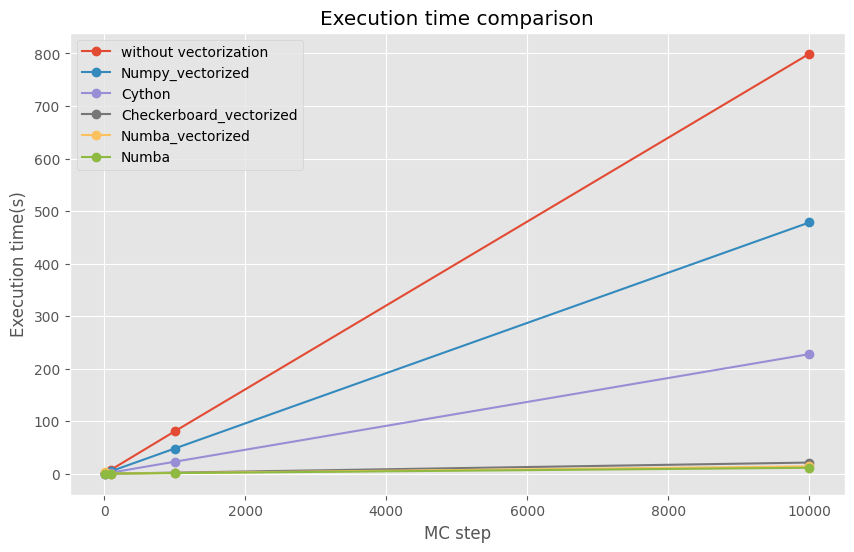

In [61]:
fig, ax = plt.subplots(figsize = (10, 6))
plt.style.use('ggplot')
data_dict = {
    'without vectorization': (values1, results1),
    'Numpy_vectorized':(values2, results2),
    'Cython':(values3, results3),
    'Checkerboard_vectorized':(values4, results4),
    'Numba_vectorized':(values5, results5),
    'Numba':(values6, results6)
}

for label, (x, y) in data_dict.items():
    plt.plot(x, y, label = label, marker = 'o', linestyle ='-')

plt.title('Execution time comparison')
plt.xlabel('MC step')
plt.ylabel('Execution time(s)')
plt.legend()
plt.show()

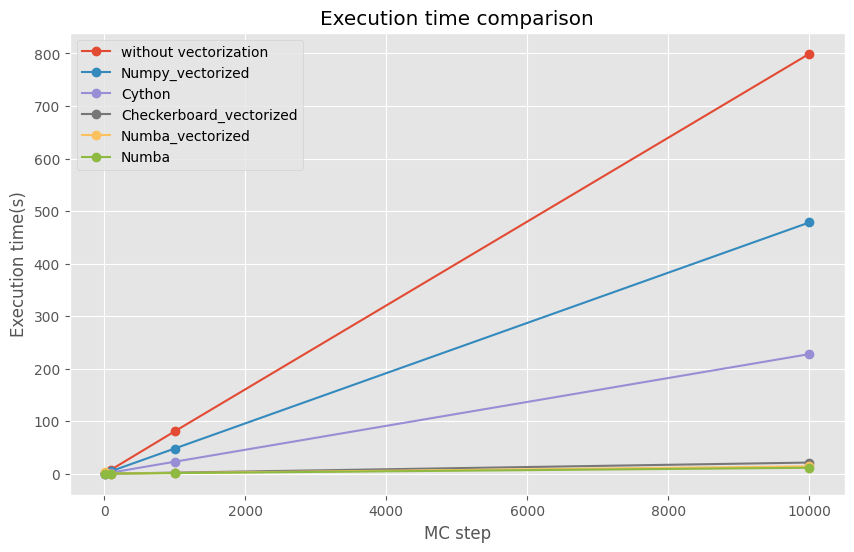

In [53]:
fig, ax = plt.subplots(figsize = (10, 6))
plt.style.use('ggplot')

plt.plot(values1, results1, label = 'without vectorization', marker = 'o', linestyle ='-')
plt.plot(values2, results2,  label = 'Numpy_vectorized', marker = 'o', linestyle ='-')
plt.plot(values3, results3,  label = 'Cython', marker = 'o', linestyle ='-')
plt.plot(values4, results4,  label = 'Checkerboard_vectorized', marker = 'o', linestyle ='-')
plt.plot(values5, results5,  label = 'Numba_vectorized', marker = 'o', linestyle ='-')
plt.plot(values6, results6,  label = 'Numba', marker = 'o', linestyle ='-')
plt.title('Execution time comparison')
plt.xlabel('MC step')
plt.ylabel('Execution time(s)')
plt.legend()
plt.show()


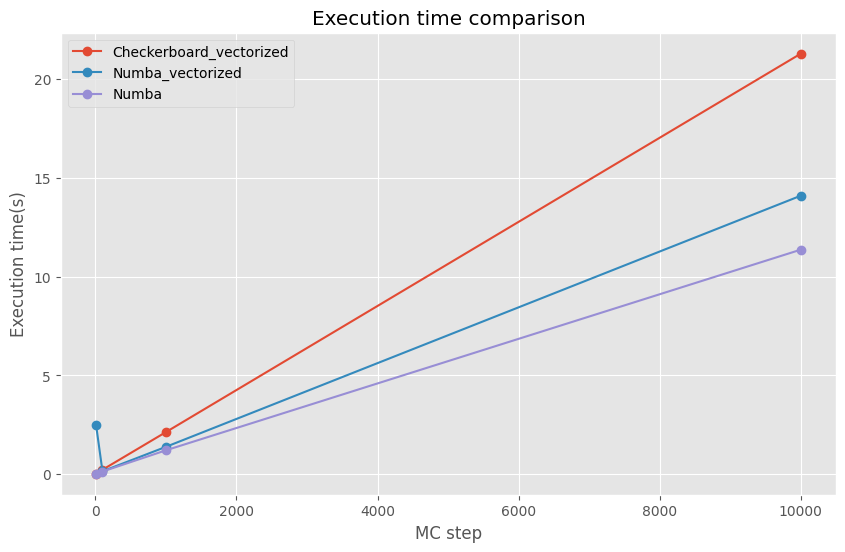

In [54]:
fig, ax = plt.subplots(figsize = (10, 6))
plt.style.use('ggplot')
plt.plot(values4, results4,  label = 'Checkerboard_vectorized', marker = 'o', linestyle ='-')
plt.plot(values5, results5,  label = 'Numba_vectorized', marker = 'o', linestyle ='-')
plt.plot(values6, results6,  label = 'Numba', marker = 'o', linestyle ='-')
plt.title('Execution time comparison')
plt.xlabel('MC step')
plt.ylabel('Execution time(s)')
plt.legend()
plt.show()

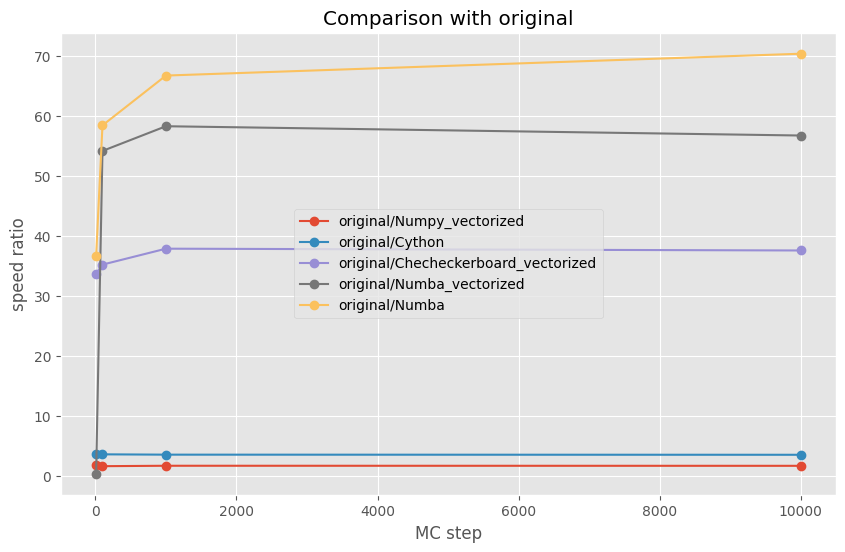

In [55]:
fig, ax = plt.subplots(figsize = (10, 6))
plt.style.use('ggplot')
plt.plot(values1, np.array(results1)/np.array(results2), label = 'original/Numpy_vectorized', marker = 'o', linestyle ='-')
plt.plot(values1, np.array(results1)/np.array(results3),  label ='original/Cython' , marker = 'o', linestyle ='-')
plt.plot(values1, np.array(results1)/np.array(results4),  label = 'original/Checheckerboard_vectorized', marker = 'o', linestyle ='-')
plt.plot(values1, np.array(results1)/np.array(results5),  label = 'original/Numba_vectorized', marker = 'o', linestyle ='-')
plt.plot(values1, np.array(results1)/np.array(results6),  label = 'original/Numba', marker = 'o', linestyle ='-')

plt.title('Comparison with original')
plt.xlabel('MC step')
plt.ylabel('speed ratio')
plt.legend()
plt.show()


In [10]:
import ll_vec as lv
import ll  as ll
import matplotlib.pyplot as plt
import time
import LLcython as lcy
import ll_checker as lc
import numpy as np
temp = np.arange(0.1,2,0.1)
nsteps = 1000
nmax = 20

In [11]:
def energy_order (module_name,nsteps, nmax,temp):
    energy = []
    order = []
    test_inputs = [
        ("LL", nsteps, nmax, t, 0) for t in temp
    ]
    for program, nsteps, nmax, temp, pflag in test_inputs:
        energy_values, order_values = module_name(program, nsteps, nmax, temp, pflag )
        energy.append(energy_values)
        order.append(order_values)

    return energy, order

In [12]:
energy1, order1 = energy_order(lc.main, nsteps, nmax,temp)

LL: Size: 20, Steps: 1000, T*: 0.100: Order: 0.979, Time: 0.733343 s
LL: Size: 20, Steps: 1000, T*: 0.200: Order: 0.946, Time: 0.753742 s
LL: Size: 20, Steps: 1000, T*: 0.300: Order: 0.915, Time: 0.777816 s
LL: Size: 20, Steps: 1000, T*: 0.400: Order: 0.897, Time: 0.761020 s
LL: Size: 20, Steps: 1000, T*: 0.500: Order: 0.874, Time: 0.785680 s
LL: Size: 20, Steps: 1000, T*: 0.600: Order: 0.790, Time: 0.785726 s
LL: Size: 20, Steps: 1000, T*: 0.700: Order: 0.820, Time: 0.781154 s
LL: Size: 20, Steps: 1000, T*: 0.800: Order: 0.646, Time: 0.818045 s
LL: Size: 20, Steps: 1000, T*: 0.900: Order: 0.682, Time: 0.802250 s
LL: Size: 20, Steps: 1000, T*: 1.000: Order: 0.373, Time: 0.792413 s
LL: Size: 20, Steps: 1000, T*: 1.100: Order: 0.340, Time: 0.795712 s
LL: Size: 20, Steps: 1000, T*: 1.200: Order: 0.326, Time: 0.800815 s
LL: Size: 20, Steps: 1000, T*: 1.300: Order: 0.290, Time: 0.841815 s
LL: Size: 20, Steps: 1000, T*: 1.400: Order: 0.312, Time: 0.837480 s
LL: Size: 20, Steps: 1000, T*: 1.5

/tmp/ipykernel_75091/829935670.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


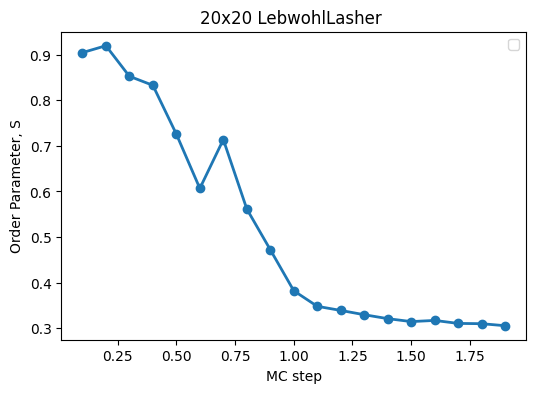

In [24]:
fig, ax = plt.subplots(figsize = (6, 4))
x_data = np.arange(0, len(order1)) 
plt.plot(temp, np.array(order1), marker='o', linestyle ='-', linewidth = 2)
#plt.plot(values2, results2,  label = 'without vectorization', marker = 'o', linestyle ='-')
#plt.title('vectorization vs original')
plt.xlabel('MC step')
plt.ylabel('Order Parameter, S')
plt.title(f'{nmax}x{nmax} LebwohlLasher ')
plt.legend()
plt.show()

In [9]:
order1

[np.float64(0.46326260160639904),
 np.float64(0.5351470179319633),
 np.float64(0.46375315315331456),
 np.float64(0.36599198052359516),
 np.float64(0.46101428351249496),
 np.float64(0.403658507132279),
 np.float64(0.42929238584855767),
 np.float64(0.44425667989352724),
 np.float64(0.33755109454639576),
 np.float64(0.29795266537414294),
 np.float64(0.2963012718896149),
 np.float64(0.2872745985574596),
 np.float64(0.28438314382577967),
 np.float64(0.27913138459033465),
 np.float64(0.2762292272494072),
 np.float64(0.2765824951193731),
 np.float64(0.27347046304075984),
 np.float64(0.27221103712900896),
 np.float64(0.27194898867256084)]

In [59]:
energy1, order1 = energy_order(ll.main,test_inputs, nsteps, nmax,temp)
energy2, order2 = energy_order(lv.main,test_inputs,nsteps, nmax,temp)
energy3, order3 = energy_order(lcy.main, test_inputs,nsteps, nmax,temp)
energy4, order4 = energy_order(lc.main, test_inputs,nsteps, nmax,temp)

LL: Size: 50, Steps: 10, T*: 0.100: Order: 0.290, Time: 0.813133 s
LL: Size: 50, Steps: 10, T*: 0.200: Order: 0.289, Time: 2.348838 s
LL: Size: 50, Steps: 10, T*: 0.300: Order: 0.300, Time: 0.857835 s
LL: Size: 50, Steps: 10, T*: 0.400: Order: 0.278, Time: 0.819168 s
LL: Size: 50, Steps: 10, T*: 0.500: Order: 0.344, Time: 0.845030 s
LL: Size: 50, Steps: 10, T*: 0.600: Order: 0.311, Time: 0.858033 s
LL: Size: 50, Steps: 10, T*: 0.700: Order: 0.278, Time: 0.901356 s
LL: Size: 50, Steps: 10, T*: 0.800: Order: 0.283, Time: 0.772635 s
LL: Size: 50, Steps: 10, T*: 0.900: Order: 0.282, Time: 0.800407 s
LL: Size: 50, Steps: 10, T*: 1.000: Order: 0.286, Time: 0.845717 s
LL: Size: 50, Steps: 10, T*: 1.100: Order: 0.271, Time: 0.815888 s
LL: Size: 50, Steps: 10, T*: 1.200: Order: 0.288, Time: 0.830623 s
LL: Size: 50, Steps: 10, T*: 1.300: Order: 0.310, Time: 0.810396 s
LL: Size: 50, Steps: 10, T*: 1.400: Order: 0.272, Time: 0.806741 s
LL: Size: 50, Steps: 10, T*: 1.500: Order: 0.259, Time: 0.8147

In [60]:
len(order1)
order1

[array([0.26222478, 0.26177457, 0.26399232, 0.26519361, 0.26854599,
        0.27027754, 0.27571959, 0.27892509, 0.2830342 , 0.29028634,
        0.29430999]),
 array([0.26173324, 0.2605228 , 0.26329089, 0.26992992, 0.27277761,
        0.27519874, 0.27728408, 0.28043263, 0.28751594, 0.28879755,
        0.29623378]),
 array([0.25665445, 0.26043089, 0.27551052, 0.27500181, 0.27862803,
        0.28406951, 0.29293981, 0.30263387, 0.30322764, 0.29962485,
        0.30877507]),
 array([0.26042118, 0.2594147 , 0.25889238, 0.25519394, 0.25887656,
        0.26155272, 0.2682517 , 0.2718548 , 0.28134006, 0.2777989 ,
        0.27854469]),
 array([0.2792334 , 0.28983787, 0.299388  , 0.31462006, 0.3255722 ,
        0.32437776, 0.33059023, 0.33297065, 0.33417578, 0.34403571,
        0.35563577]),
 array([0.26570321, 0.26303598, 0.26804668, 0.27934591, 0.26435278,
        0.27754315, 0.27324113, 0.28523234, 0.28822257, 0.31077558,
        0.31408754]),
 array([0.26447361, 0.26722592, 0.27723829, 0.282845

In [53]:
energy3

[<MemoryView of 'ndarray' at 0x745240e0a0c0>,
 <MemoryView of 'ndarray' at 0x745240e0bac0>,
 <MemoryView of 'ndarray' at 0x745240e08a00>,
 <MemoryView of 'ndarray' at 0x745240e14860>,
 <MemoryView of 'ndarray' at 0x745240e14d40>,
 <MemoryView of 'ndarray' at 0x745240e14a00>,
 <MemoryView of 'ndarray' at 0x745240e4d560>,
 <MemoryView of 'ndarray' at 0x745240e4d8a0>,
 <MemoryView of 'ndarray' at 0x745240e4dbe0>,
 <MemoryView of 'ndarray' at 0x745240e4df20>,
 <MemoryView of 'ndarray' at 0x745240e4e260>,
 <MemoryView of 'ndarray' at 0x745240e4e5a0>,
 <MemoryView of 'ndarray' at 0x745240e4e8e0>,
 <MemoryView of 'ndarray' at 0x745240e4ec20>,
 <MemoryView of 'ndarray' at 0x745240e4ef60>,
 <MemoryView of 'ndarray' at 0x745240e4f2a0>,
 <MemoryView of 'ndarray' at 0x745240e4f5e0>,
 <MemoryView of 'ndarray' at 0x745240e4f920>,
 <MemoryView of 'ndarray' at 0x745240e4fc60>]

In [48]:
energy4

[array([-2513.74178419, -3170.83884859, -3729.20863364, -4223.18100735,
        -4696.61251992, -5155.43710919, -5548.79744018, -5888.51977327,
        -6237.1619182 , -6530.60564031, -6784.59164134]),
 array([-2444.20612293, -3296.45864462, -4005.48178895, -4662.10042018,
        -5190.13251314, -5657.03040328, -6077.39588689, -6432.68813229,
        -6678.10343522, -6944.58388022, -7174.55462914]),
 array([-2455.57953501, -3525.53584887, -4423.99754572, -5068.94045676,
        -5623.88835581, -6037.93665704, -6369.5720121 , -6648.46254107,
        -6919.576511  , -7176.68816018, -7363.56462001]),
 array([-2547.93866468, -3739.42401964, -4588.5590468 , -5174.88168953,
        -5610.93075402, -6021.77887045, -6343.67441412, -6636.90160447,
        -6793.16204638, -6980.83897939, -7149.45965976]),
 array([-2323.48449838, -3848.41754662, -4658.70902171, -5273.44111149,
        -5759.83973743, -6089.61619639, -6322.17701888, -6497.18395677,
        -6693.3237924 , -6825.61898594, -7061.74

In [ ]:
nsteps

TypeError: Cannot index with type '<class 'NoneType'>'

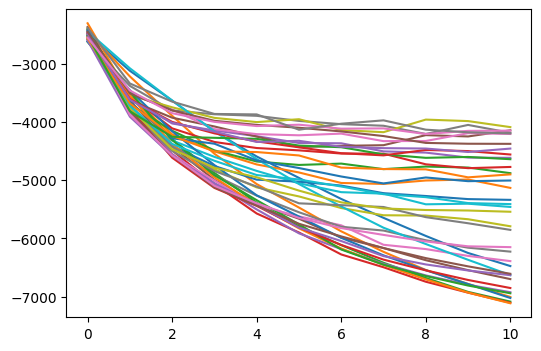

In [54]:
import matplotlib.pyplot as plt 
fig, ax = plt.subplots(figsize = (6, 4))
x_data = np.arange(0, nsteps+1) 
energy_list = [energy1, energy2, energy3, energy4]
for i in energy_list:
    for j in range(0, len(temp)):
        plt.plot(x_data, i[j])

plt.xlabel('MC step')
plt.ylabel('Reduced Energy U/ε')
plt.title(f'Reduced Temperature , T*={temp}')
plt.legend()
plt.show()


#plt.plot(values2, results2,  label = 'without vectorization', marker = 'o', linestyle ='-')
#plt.title('vectorization vs original')


In [ ]:
import ll_ene_order as leo

program, nsteps, nmax, temp, pflag = ("LL", 10, 20, 0.65, 0)
energy, order = leo.main(program, nsteps, nmax, temp, pflag )



LL: Size: 20, Steps: 10, T*: 0.650: Order: 0.406, Time: 0.148778 s


In [4]:
import numpy as np

/tmp/ipykernel_60629/2250545546.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


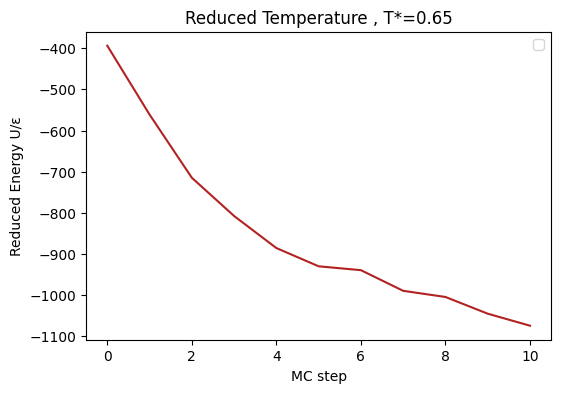

In [5]:
fig, ax = plt.subplots(figsize = (6, 4))
x_data = np.arange(0, len(energy)) 
plt.plot(x_data, energy, linestyle ='-', color='firebrick')
#plt.plot(values2, results2,  label = 'without vectorization', marker = 'o', linestyle ='-')
#plt.title('vectorization vs original')
plt.xlabel('MC step')
plt.ylabel('Reduced Energy U/ε')
plt.title(f'Reduced Temperature , T*={temp}')
plt.legend()
plt.show()


/tmp/ipykernel_2027/616990779.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


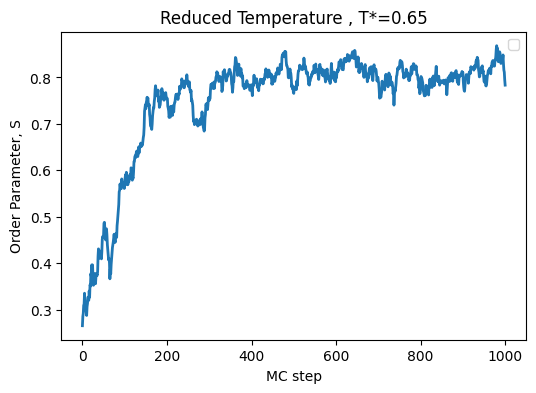

In [8]:
fig, ax = plt.subplots(figsize = (6, 4))
x_data = np.arange(0, len(energy)) 
plt.plot(x_data, order, linestyle ='-', linewidth = 2)
#plt.plot(values2, results2,  label = 'without vectorization', marker = 'o', linestyle ='-')
#plt.title('vectorization vs original')
plt.xlabel('MC step')
plt.ylabel('Order Parameter, S')
plt.title(f'Reduced Temperature , T*={temp}')
plt.legend()
plt.show()

In [15]:
len(x_data)

101

In [16]:
x_data

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100])

In [12]:
len(energy)

101

In [ ]:
import LebwohlLasher_energy_order as leo
import matplotlib.pyplot as plt 
program, nsteps, nmax, temp, pflag = ("LL", 1000, 20, 0.65, 0)
energy, order = leo.main(program, nsteps, nmax, temp, pflag )

LL: Size: 50, Steps: 100, T*: 0.650: Order: 0.391, Time: 9.078979 s


/tmp/ipykernel_16648/347312933.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


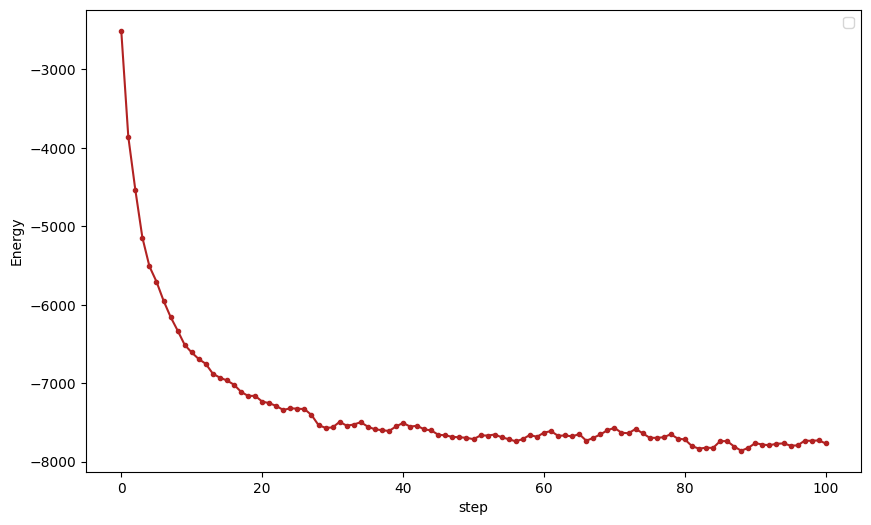

In [35]:
fig, ax = plt.subplots(figsize = (10, 6))
x_data = np.arange(0, len(energy)) 
plt.plot(x_data, energy, marker = '.', linestyle ='-', color='firebrick')
#plt.plot(values2, results2,  label = 'without vectorization', marker = 'o', linestyle ='-')
#plt.title('vectorization vs original')
plt.xlabel('step')
plt.ylabel('Energy')
plt.legend()
plt.show()